In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_excel(r"A:\Projects\Data Science\Customer Segmentation\Online Retail Dataset\Online_Retail.xlsx")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df['Country'] = df['Country'].astype('category')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 29.5+ MB


In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df = df.dropna(subset=['CustomerID'])
# we are removing the unknown customers as they dont take part in customer segmentation, useless data for our goal

In [11]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
df['CustomerID'] = df['CustomerID'].astype(str)

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [14]:
print((df['Quantity'] <= 0).sum())
# this means there are 8905 transactions where the quantity is negative which is actually invalid

8905


In [15]:
print((df['UnitPrice'] <= 0).sum())
# this means there are 2515 transactions where the price per unit is equal to or less than 0 (items that are free or invalid items)

40


In [16]:
df = df[df['UnitPrice'] > 0 ]

In [17]:
print((df['UnitPrice'] <= 0).sum())

0


In [18]:
df = df[df['Quantity'] > 0 ]

In [19]:
print((df['Quantity'] <= 0).sum())

0


In [20]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [21]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  object        
 7   Country      397884 non-null  category      
 8   TotalPrice   397884 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.7+ MB


In [23]:
print((df['TotalPrice'] < 0).sum())

0


In [24]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [25]:
grouped = df.groupby('CustomerID')

In [26]:
recency = (reference_date - grouped['InvoiceDate'].max()).dt.days

In [27]:
frequency = grouped['InvoiceNo'].nunique()

In [28]:
monetary = grouped['TotalPrice'].sum()

In [29]:
rfm = pd.concat([recency, frequency, monetary], axis=1)

In [30]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [31]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [32]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6+ KB


In [33]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [34]:
print(rfm['Monetary'].skew())
# >1.0 means highly positively skewed

19.32495323682082


In [35]:
print(rfm['Frequency'].skew())

12.067030826322075


In [36]:
print(rfm['Recency'].skew())

1.2460475158158468


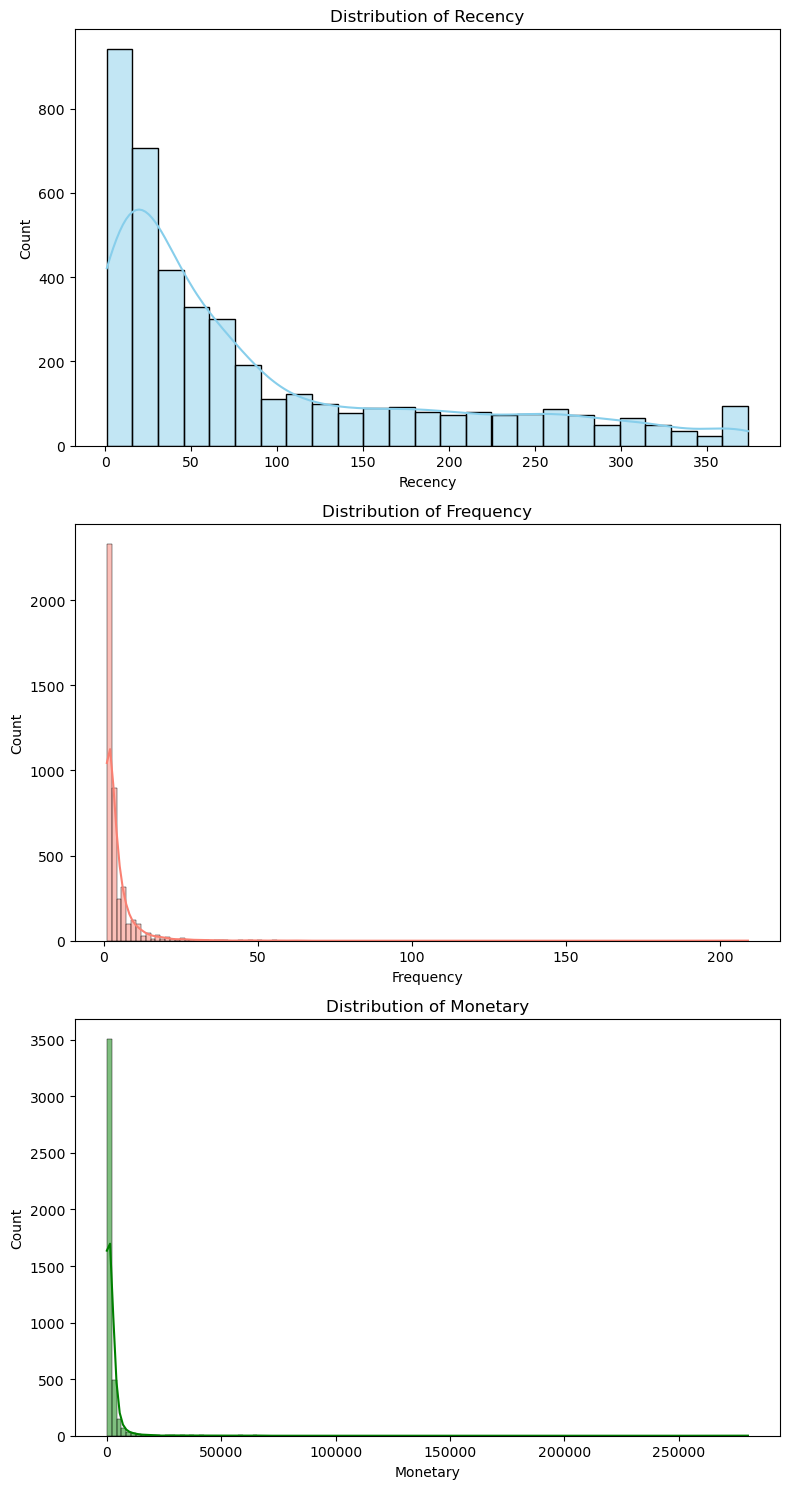

In [37]:
## Histogram plot for RFM
# 1. Setup a figure with 1 row and 3 columns
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

# 2. Map each column to an axis (axes[0], axes[1], axes[2])
sns.histplot(data=rfm, x="Recency", kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Recency')

sns.histplot(data=rfm, x="Frequency", kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Frequency')

sns.histplot(data=rfm, x="Monetary", kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribution of Monetary')

# 3. Prevent label overlapping
plt.tight_layout()
plt.show()

In [38]:
# Recency -> less inactive users there are users with atleast 1 recent transaction
# Frequency -> People who are loyal are less that is high frequency count is less
# Monetary -> same as frequency

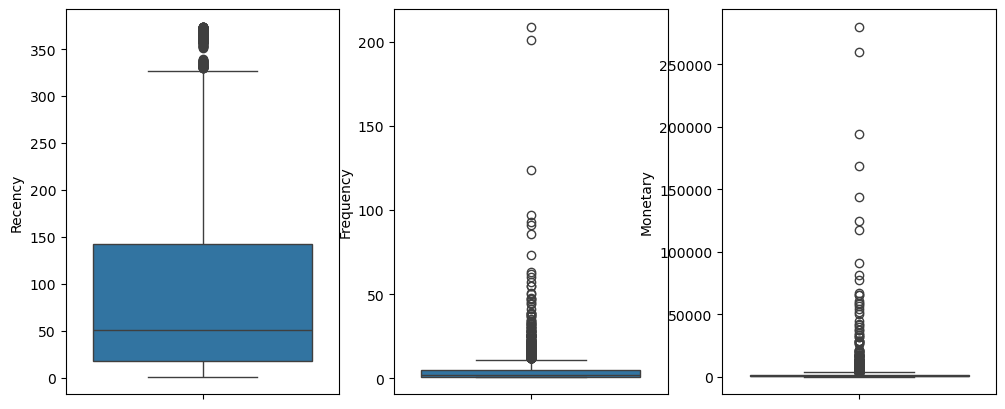

In [39]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.boxplot(y=rfm['Recency'])

plt.subplot(1,3,2)
sns.boxplot(y=rfm['Frequency'])

plt.subplot(1,3,3)
sns.boxplot(y=rfm['Monetary'])

plt.show()

In [40]:
#Recency -> Wider spread, Some high values (Mix of active and inactive customers)
#Frequency -> Box compressed near bottom, Few extreme points above (Most customers purchase rarely, few are highly frequent)
#Monetary -> Very compressed box, Many extreme outliers (Few customers contribute very high revenue)

In [41]:
# STEP-1
# We need to apply transformation in the data as it Compresses large values so distribution becomes balanced
# We are using Log Transformation as 1)Shrinks very large values 2)Keeps order of data intact 3)Works perfectly for right-skewed data

# STEP-2

# Scaling (normalize features)
# We need scaling to Bring all features to same scale so clustering is fair
# Mean = 0  Std = 1 (Normal Distribution)

In [42]:
# Step 1: Transformation
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [43]:
# Step 2: Scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [44]:
rfm_scaled

array([[ 1.46199281, -0.95521426,  3.70622476],
       [-2.03873442,  1.07442519,  1.41184341],
       [ 0.37310424,  0.38630445,  0.7164889 ],
       ...,
       [-1.21893976, -0.36158278, -1.11812113],
       [-1.65755161,  2.17800394,  0.83829669],
       [-0.03473174,  0.05960547,  0.73400231]], shape=(4338, 3))

In [45]:
rfm_log.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.593627
std,1.340261,0.683104,1.257578
min,0.693147,0.693147,1.558145
25%,2.944439,0.693147,5.731446
50%,3.951244,1.098612,6.515431
75%,4.962845,1.791759,7.416222
max,5.926926,5.347108,12.543284


In [46]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [47]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

In [48]:
rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-0.955214,3.706225
12347.0,-2.038734,1.074425,1.411843
12348.0,0.373104,0.386304,0.716489
12349.0,-0.623086,-0.955214,0.698739
12350.0,1.424558,-0.955214,-0.618962


In [49]:
rfm_scaled_df.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,-8.025955e-17,-8.189750e-18,2.817274e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341296e+00,-9.552143e-01,-4.004574e+00
25%,-6.613615e-01,-9.552143e-01,-6.856676e-01
50%,8.992557e-02,-3.615828e-01,-6.218718e-02
75%,8.447915e-01,6.532370e-01,6.541861e-01
max,1.564198e+00,5.858535e+00,4.731591e+00


In [50]:
# Now we dive in model building 
# we are using elbow plot to identify the best value of k

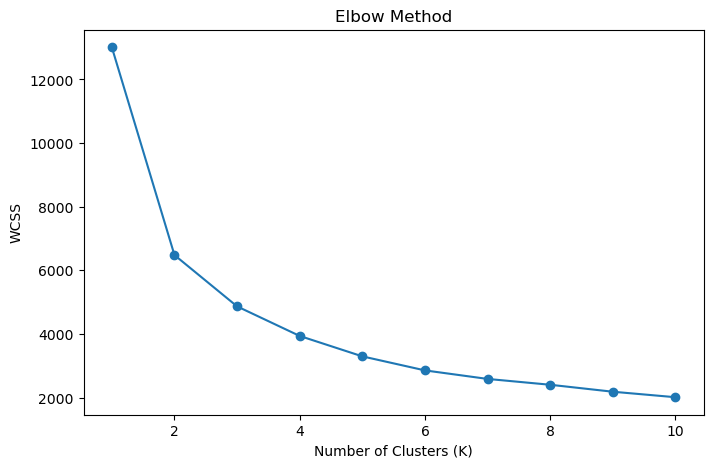

In [51]:
wcss = []

# Try K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [52]:
# We are also calculating the silhoutte scores to verify the value of k

In [53]:
sil_scores = []

K_range = range(2, 11)  # starts from 2 (important)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled_df)
    
    score = silhouette_score(rfm_scaled_df, labels)
    sil_scores.append(score)

# Print results
for k, score in zip(K_range, sil_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4332
K = 3, Silhouette Score = 0.3360
K = 4, Silhouette Score = 0.3371
K = 5, Silhouette Score = 0.3173
K = 6, Silhouette Score = 0.3143
K = 7, Silhouette Score = 0.2875
K = 8, Silhouette Score = 0.2682
K = 9, Silhouette Score = 0.2784
K = 10, Silhouette Score = 0.2791


In [54]:
# From the elbow plot best k value is 3 or 4 but calculating the Silhoutte scores we get that the score dropped drastically after k = 2 but is almost 
# decreasing in the same manner for the rest of the data. But k=2 means that we are clustering the data as High valued customer or low valued
# So that's why we should take k = 3/4 for this buisness perspective

In [55]:
# Applying KMeans
# K = 3
kmeans3 = KMeans(n_clusters=3, random_state=42)
rfm_scaled_df['Cluster_3'] = kmeans3.fit_predict(rfm_scaled_df[['Recency','Frequency','Monetary']])

# K = 4
kmeans4 = KMeans(n_clusters=4, random_state=42)
rfm_scaled_df['Cluster_4'] = kmeans4.fit_predict(rfm_scaled_df[['Recency','Frequency','Monetary']])

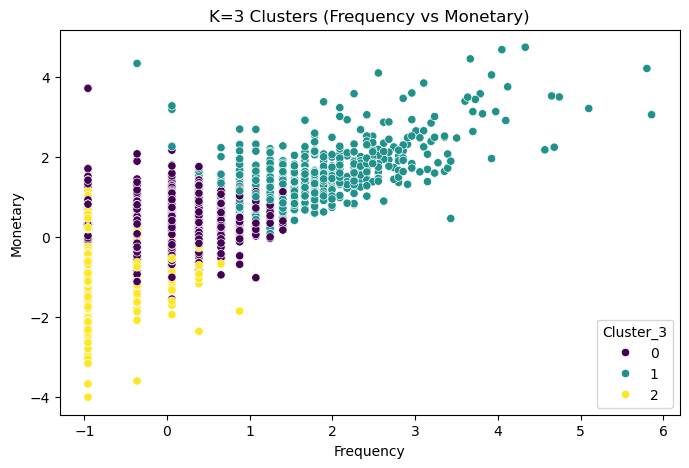

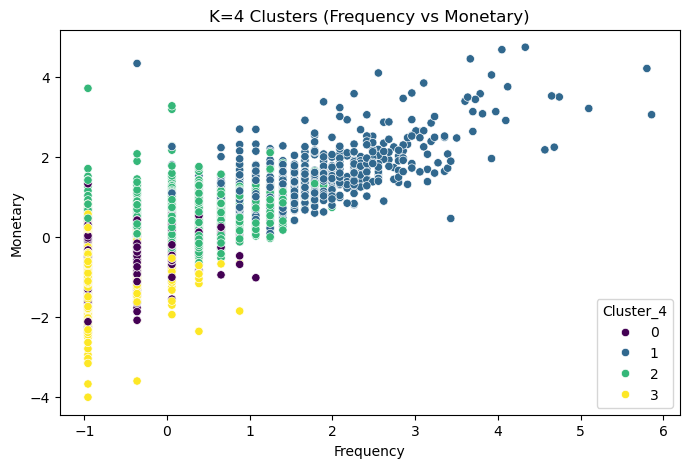

In [56]:
# K = 3
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=rfm_scaled_df['Frequency'],
    y=rfm_scaled_df['Monetary'],
    hue=rfm_scaled_df['Cluster_3'],
    palette='viridis'
)
plt.title('K=3 Clusters (Frequency vs Monetary)')
plt.show()


# K = 4
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=rfm_scaled_df['Frequency'],
    y=rfm_scaled_df['Monetary'],
    hue=rfm_scaled_df['Cluster_4'],
    palette='viridis'
)
plt.title('K=4 Clusters (Frequency vs Monetary)')
plt.show()

In [57]:
rfm['Cluster_3'] = rfm_scaled_df['Cluster_3']

In [58]:
# k = 4 is not giving better boundaries thats why we stay with k = 3

In [59]:
# Cluster_3 shows -
# Cluster 1 → High Value (Best)
# Cluster 0 → Moderate / Regular
# Cluster 2 → At Risk

In [60]:
rfm['Segment'] = rfm['Cluster_3'].map({
    1: 'High Value',
    0: 'Regular',
    2: 'At Risk'
})

In [61]:
rfm.head()

,Recency,Frequency,Monetary,Cluster_3,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,0,Regular
12347.0,2,7,4310.00,1,High Value
12348.0,75,4,1797.24,0,Regular
12349.0,19,1,1757.55,0,Regular
12350.0,310,1,334.40,2,At Risk


In [62]:
high_value_customers = rfm[rfm['Segment'] == 'High Value']

In [63]:
regular_customers = rfm[rfm['Segment'] == 'Regular']

In [64]:
at_risk_customers = rfm[rfm['Segment'] == 'At Risk']

In [65]:
high_value_ids = high_value_customers.index.tolist()
regular_ids = regular_customers.index.tolist()
at_risk_ids = at_risk_customers.index.tolist()

In [66]:
high_value_customers.sort_values(by='Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary,Cluster_3,Segment
CustomerID,,,,,
14646.0,2,73,280206.02,1,High Value
18102.0,1,60,259657.30,1,High Value
17450.0,8,46,194550.79,1,High Value
16446.0,1,2,168472.50,1,High Value
14911.0,1,201,143825.06,1,High Value
12415.0,24,21,124914.53,1,High Value
14156.0,10,55,117379.63,1,High Value
17511.0,3,31,91062.38,1,High Value
16029.0,39,63,81024.84,1,High Value


In [67]:
at_risk_customers.sort_values(by='Recency', ascending=False).head(10)

,Recency,Frequency,Monetary,Cluster_3,Segment
CustomerID,,,,,
18074.0,374,1,489.60,2,At Risk
16583.0,374,1,233.45,2,At Risk
14729.0,374,1,313.49,2,At Risk
17908.0,374,1,243.28,2,At Risk
13747.0,374,1,79.60,2,At Risk
12791.0,374,1,192.60,2,At Risk
17968.0,374,1,277.35,2,At Risk
12855.0,373,1,38.10,2,At Risk
18011.0,373,1,102.79,2,At Risk


In [68]:
regular_customers.sort_values(by='Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary,Cluster_3,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,0,Regular
12536.0,43,3,12601.83,0,Regular
12409.0,79,3,11072.67,0,Regular
12590.0,211,2,9864.26,0,Regular
12435.0,80,2,7829.89,0,Regular
16532.0,18,3,6748.80,0,Regular
16182.0,72,4,6617.65,0,Regular
12359.0,58,4,6372.58,0,Regular
12357.0,33,1,6207.67,0,Regular


In [69]:
rfm['Segment'].value_counts()

Segment
At Risk       1866
Regular       1696
High Value     776
Name: count, dtype: int64

In [70]:
df[df['CustomerID'] == '14646.0'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 2076 entries, 37952 to 537783
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    2076 non-null   object        
 1   StockCode    2076 non-null   object        
 2   Description  2076 non-null   object        
 3   Quantity     2076 non-null   int64         
 4   InvoiceDate  2076 non-null   datetime64[ns]
 5   UnitPrice    2076 non-null   float64       
 6   CustomerID   2076 non-null   object        
 7   Country      2076 non-null   category      
 8   TotalPrice   2076 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 149.3+ KB


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  object        
 7   Country      397884 non-null  category      
 8   TotalPrice   397884 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.7+ MB


In [72]:
rfm.loc['14646.0']

Recency               2
Frequency            73
Monetary      280206.02
Cluster_3             1
Segment      High Value
Name: 14646.0, dtype: object

In [73]:
rfm.loc['16182.0']

Recency           72
Frequency          4
Monetary     6617.65
Cluster_3          0
Segment      Regular
Name: 16182.0, dtype: object

In [74]:
rfm.loc['12346.0']

Recency          326
Frequency          1
Monetary     77183.6
Cluster_3          0
Segment      Regular
Name: 12346.0, dtype: object

In [75]:
high_value = rfm[rfm['Segment'] == 'High Value']

In [80]:
rfm[
    (rfm['Recency'] < rfm['Recency'].quantile(0.25)) &   # recent
    (rfm['Frequency'] > rfm['Frequency'].quantile(0.75)) &
    (rfm['Monetary'] > rfm['Monetary'].quantile(0.75)) &
    (rfm['Segment'] != 'High Value')
]

,Recency,Frequency,Monetary,Cluster_3,Segment
CustomerID,,,,,
13650.0,17,6,1836.34,0,Regular
17519.0,17,6,1844.02,0,Regular


In [84]:
rfm[
    (rfm['Monetary'] > rfm['Monetary'].quantile(0.75)) &
    (rfm['Recency'] > rfm['Recency'].quantile(0.75))
].count()

Recency      50
Frequency    50
Monetary     50
Cluster_3    50
Segment      50
dtype: int64

In [85]:
rfm[
    (rfm['Monetary'] > rfm['Monetary'].quantile(0.75)) &  # high monetary
    (rfm['Recency'] > rfm['Recency'].quantile(0.75))      # high recency 
]

,Recency,Frequency,Monetary,Cluster_3,Segment
CustomerID,,,,,
12346.0,326,1,77183.600,0,Regular
12383.0,185,5,1850.560,0,Regular
12405.0,149,1,1710.390,2,At Risk
12424.0,163,2,1760.960,0,Regular
12501.0,337,1,2169.390,2,At Risk
12585.0,234,2,2040.100,2,At Risk
12590.0,211,2,9864.260,0,Regular
12625.0,212,2,2683.820,0,Regular
12653.0,149,2,2209.850,0,Regular


In [86]:
rfm[
    (rfm['Recency'] < rfm['Recency'].quantile(0.25)) &   # recent
    (rfm['Frequency'] >= rfm['Frequency'].quantile(0.5)) &  # medium-high
    (rfm['Monetary'] >= rfm['Monetary'].quantile(0.5)) &    # medium
    (rfm['Monetary'] < rfm['Monetary'].quantile(0.75))      # NOT top spenders
]

,Recency,Frequency,Monetary,Cluster_3,Segment
CustomerID,,,,,
12358.0,2,2,1168.06,0,Regular
12364.0,8,4,1313.10,0,Regular
12421.0,16,4,807.04,0,Regular
12464.0,10,8,1212.05,1,High Value
12465.0,17,2,742.19,0,Regular
...,...,...,...,...,...
18096.0,12,3,911.15,0,Regular
18130.0,15,3,1059.39,0,Regular
18156.0,13,2,734.94,0,Regular


In [87]:
# from above we can create 2 new classes - high potential and lost potential

In [88]:
# High Potential
# 1) good frequency 2) recent transaction 3) medium spenders not exactly the topmost ones

# Lost Potential
# 1) high recency i.e. last item bought long time ago 2) high monetory spenders

In [89]:
# Segment Final is the new Final Segments


rfm['Segment_Final'] = rfm['Segment']

# Lost High Value (highest priority)
rfm.loc[
    (rfm['Monetary'] > rfm['Monetary'].quantile(0.75)) &
    (rfm['Recency'] > rfm['Recency'].quantile(0.75)),
    'Segment_Final'
] = 'Lost High Value'

# Potential High Value
rfm.loc[
    (rfm['Recency'] < rfm['Recency'].quantile(0.25)) &
    (rfm['Frequency'] >= rfm['Frequency'].quantile(0.5)) &
    (rfm['Monetary'] >= rfm['Monetary'].quantile(0.5)) &
    (rfm['Monetary'] < rfm['Monetary'].quantile(0.75)),
    'Segment_Final'
] = 'Potential High Value'

In [92]:
rfm['Segment_Final'].value_counts()

Segment_Final
At Risk                 1853
Regular                 1451
High Value               711
Potential High Value     273
Lost High Value           50
Name: count, dtype: int64

In [93]:
rfm.groupby('Segment_Final')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment_Final,,,
At Risk,167.003778,1.350243,349.742321
High Value,15.718706,13.796062,8313.712504
Lost High Value,217.260000,4.240000,6040.696220
Potential High Value,8.479853,4.395604,1110.702894
Regular,46.596141,3.314266,1204.017293


In [94]:
rfm.groupby('Segment_Final')[['Recency','Frequency','Monetary']].median()

,Recency,Frequency,Monetary
Segment_Final,,,
At Risk,158.0,1.0,295.00
High Value,10.0,10.0,3877.52
Lost High Value,201.5,3.0,2421.98
Potential High Value,9.0,4.0,1078.23
Regular,34.0,3.0,939.32
